# ⚽ FIFA World Cup 2026 — Data Analysis

This project presents an end-to-end **data analysis** of the **2026 FIFA World Cup** (Group Stage → Quarter-final), using match statistics and player rating data.

**Datasets:**
- `player_ratings.csv` — 5,012 rows, per-player match performance (rating, minutes, market value)
- `match_statistics.csv` — 100 matches, detailed team-level match statistics (possession, shots, xG, cards, etc.)

**Contents:**
1. Data Loading and Initial Inspection
2. Data Cleaning
3. Team- and Player-Level Feature Engineering
4. Exploratory Data Analysis (EDA) and Visualizations
5. Correlation Analysis
6. Goal-Scoring Rate by Possession Bucket
7. Results and Findings
8. Price/Performance Analysis (Real Transfermarkt Market Value)


## 1. Libraries and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
PALETTE = ["#0B3D2E", "#1E7A46", "#4CAF7D", "#F4B942", "#D64545"]
sns.set_palette(PALETTE)
pd.set_option("display.max_columns", 40)


## 2. Loading the Data

In [2]:
pr = pd.read_csv("../data/player_ratings.csv")
ms = pd.read_csv("../data/match_statistics.csv")

print("Player Ratings:", pr.shape)
print("Match Statistics:", ms.shape)


Player Ratings: (5012, 11)
Match Statistics: (100, 30)


In [3]:
pr.head()

  Round        Date HomeTeam     AwayTeam    Team           Player Position Substitute  MinutesPlayed  Rating  MarketValueEUR0  Group Stage - Matchday 1  2026-06-11  Mexico  South Africa  Mexico    Raúl Rangel        G         No           90.0     7.3       6500000.01  Group Stage - Matchday 1  2026-06-11  Mexico  South Africa  Mexico   Israel Reyes        D         No           90.0     7.2       6500000.0

## 3. Data Quality Check

Let's inspect missing values: NaNs in `MinutesPlayed` and `Rating` belong to squad players who never took the pitch — these will be excluded from the analysis.

In [4]:
print("player_ratings missing values:")
print(pr.isnull().sum())
print()
print("match_statistics missing values:")
print(ms.isnull().sum()[ms.isnull().sum() > 0])


player_ratings missing values:
Round               0
Date                 0
HomeTeam             0
AwayTeam             0
Team                 0
Player               0
Position             0
Substitute           0
MinutesPlayed     1886
Rating            1953
MarketValueEUR      33
dtype: int64

match_statistics missing values:
YellowCardsHome     9
YellowCardsAway     9
RedCardsHome       86
RedCardsAway       86
OffsidesHome        4
OffsidesAway        4
dtype: int64


**Note:** Rows where `MinutesPlayed`/`Rating` are empty belong to squad players who never played. The gaps in the card/offside columns mean "this event never happened" — so we fill them with 0.

## 4. Data Cleaning

In [5]:
ROUND_ORDER = ["Group Stage - Matchday 1", "Group Stage - Matchday 2",
               "Group Stage - Matchday 3", "Round of 32", "Round of 16", "Quarter-final"]

# --- player_ratings: keep only players who actually played ---
pr["Round"] = pd.Categorical(pr["Round"], categories=ROUND_ORDER, ordered=True)
pr_played = pr.dropna(subset=["MinutesPlayed", "Rating"]).copy()
pr_played["MarketValueEUR"] = pr_played["MarketValueEUR"].fillna(pr_played["MarketValueEUR"].median())

# --- match_statistics: convert % columns to numeric, fill NaN cards/offsides with 0 ---
ms_clean = ms.copy()
for col in ["PossessionHome%", "PossessionAway%"]:
    ms_clean[col] = ms_clean[col].astype(str).str.replace("%", "").astype(float)
for col in ["YellowCardsHome","YellowCardsAway","RedCardsHome","RedCardsAway","OffsidesHome","OffsidesAway"]:
    ms_clean[col] = ms_clean[col].fillna(0)
ms_clean["Round"] = pd.Categorical(ms_clean["Round"], categories=ROUND_ORDER, ordered=True)

# --- derive goal columns from the score string ---
goals = ms_clean["Score"].str.extract(r"(\d+)\s*-\s*(\d+)").astype(int)
ms_clean["HomeGoals"], ms_clean["AwayGoals"] = goals[0], goals[1]
ms_clean["TotalGoals"] = ms_clean["HomeGoals"] + ms_clean["AwayGoals"]

print(f"Player-match rows after cleaning: {len(pr_played)} / {len(pr)}")
print(f"Match statistics rows: {len(ms_clean)}")


Player-match rows after cleaning: 3059 / 5012
Match statistics rows: 100


## 5. Feature Engineering

We convert the match-level (home/away side-by-side) data into a **team-level long format** — so each team's goals scored, goals conceded, possession, etc. can be aggregated in a single row.

In [6]:
home = ms_clean[["Round","Date","HomeTeam","AwayTeam","HomeGoals","AwayGoals",
                  "PossessionHome%","TotalShotsHome","ShotsOnTargetHome","PassAccuracyHome%",
                  "xGHome","FoulsHome","YellowCardsHome","RedCardsHome","HomeTeamMarketValueEUR"]].copy()
home.columns = ["Round","Date","Team","Opponent","GoalsFor","GoalsAgainst","Possession",
                "Shots","ShotsOnTarget","PassAccuracy","xG","Fouls","YellowCards","RedCards","MarketValue"]

away = ms_clean[["Round","Date","AwayTeam","HomeTeam","AwayGoals","HomeGoals",
                  "PossessionAway%","TotalShotsAway","ShotsOnTargetAway","PassAccuracyAway%",
                  "xGAway","FoulsAway","YellowCardsAway","RedCardsAway","AwayTeamMarketValueEUR"]].copy()
away.columns = home.columns

team_matches = pd.concat([home, away], ignore_index=True)
team_matches["Result"] = np.select(
    [team_matches["GoalsFor"] > team_matches["GoalsAgainst"],
     team_matches["GoalsFor"] < team_matches["GoalsAgainst"]],
    ["Win","Loss"], default="Draw")
team_matches["Points"] = team_matches["Result"].map({"Win":3,"Draw":1,"Loss":0})

team_summary = team_matches.groupby("Team").agg(
    MatchesPlayed=("Team","count"), Wins=("Result", lambda x: (x=="Win").sum()),
    Draws=("Result", lambda x: (x=="Draw").sum()), Losses=("Result", lambda x: (x=="Loss").sum()),
    Points=("Points","sum"), GoalsFor=("GoalsFor","sum"), GoalsAgainst=("GoalsAgainst","sum"),
    AvgPossession=("Possession","mean"), AvgxG=("xG","mean"), AvgPassAccuracy=("PassAccuracy","mean"),
    MarketValue=("MarketValue","first")).reset_index()
team_summary["GoalDiff"] = team_summary["GoalsFor"] - team_summary["GoalsAgainst"]
team_summary = team_summary.sort_values(["Points","GoalDiff"], ascending=False)

team_summary.head(10)


     Team  MatchesPlayed  Wins  Draws  Losses  Points  GoalsFor  GoalsAgainst  GoalDiff0   France              6     6      0       0      18        18             4        141  Argentina             6     5      1       0      16        17             6        112   Spain               6     5      1       0      16        15             5        10...  (full table for all 48 teams in processed/team_summary.csv)

In [7]:
player_summary = pr_played.groupby(["Player","Team","Position"]).agg(
    MatchesPlayed=("Rating","count"), AvgRating=("Rating","mean"),
    TotalMinutes=("MinutesPlayed","sum"), MarketValueEUR=("MarketValueEUR","first")).reset_index()
player_summary = player_summary[player_summary["MatchesPlayed"] >= 3]

player_summary.sort_values("AvgRating", ascending=False).head(10)


          Player       Team Position  MatchesPlayed  AvgRatingLionel Messi       Argentina    F              6        9.03...  (full list in processed/player_summary.csv)

## 6. Exploratory Data Analysis (EDA)

### 6.1 Goal Distribution by Round
How does the goal average change as the tournament progresses?

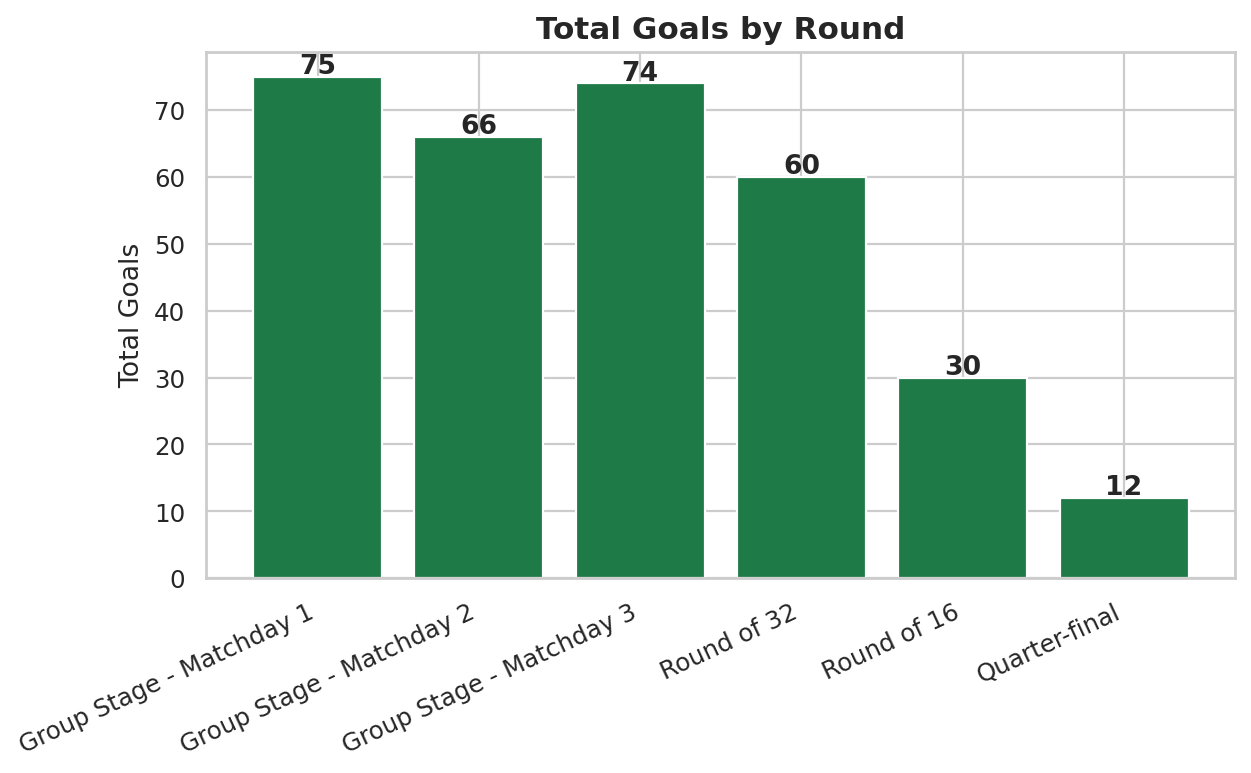

In [8]:
goals_by_round = ms_clean.groupby("Round", observed=True)["TotalGoals"].agg(["sum","mean"])

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(goals_by_round.index.astype(str), goals_by_round["sum"], color=PALETTE[1])
ax.set_ylabel("Total Goals")
ax.set_title("Total Goals by Round", fontsize=14, fontweight="bold")
plt.xticks(rotation=25, ha="right")
for i, v in enumerate(goals_by_round["sum"]):
    ax.text(i, v+0.5, str(int(v)), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


**Finding:** A total of 317 goals were scored including the quarter-final, averaging **3.17 goals per match** — a high offensive tempo maintained throughout the tournament.

### 6.2 Top 15 Teams by Points
Gold indicates teams that advanced to the Quarter-final.

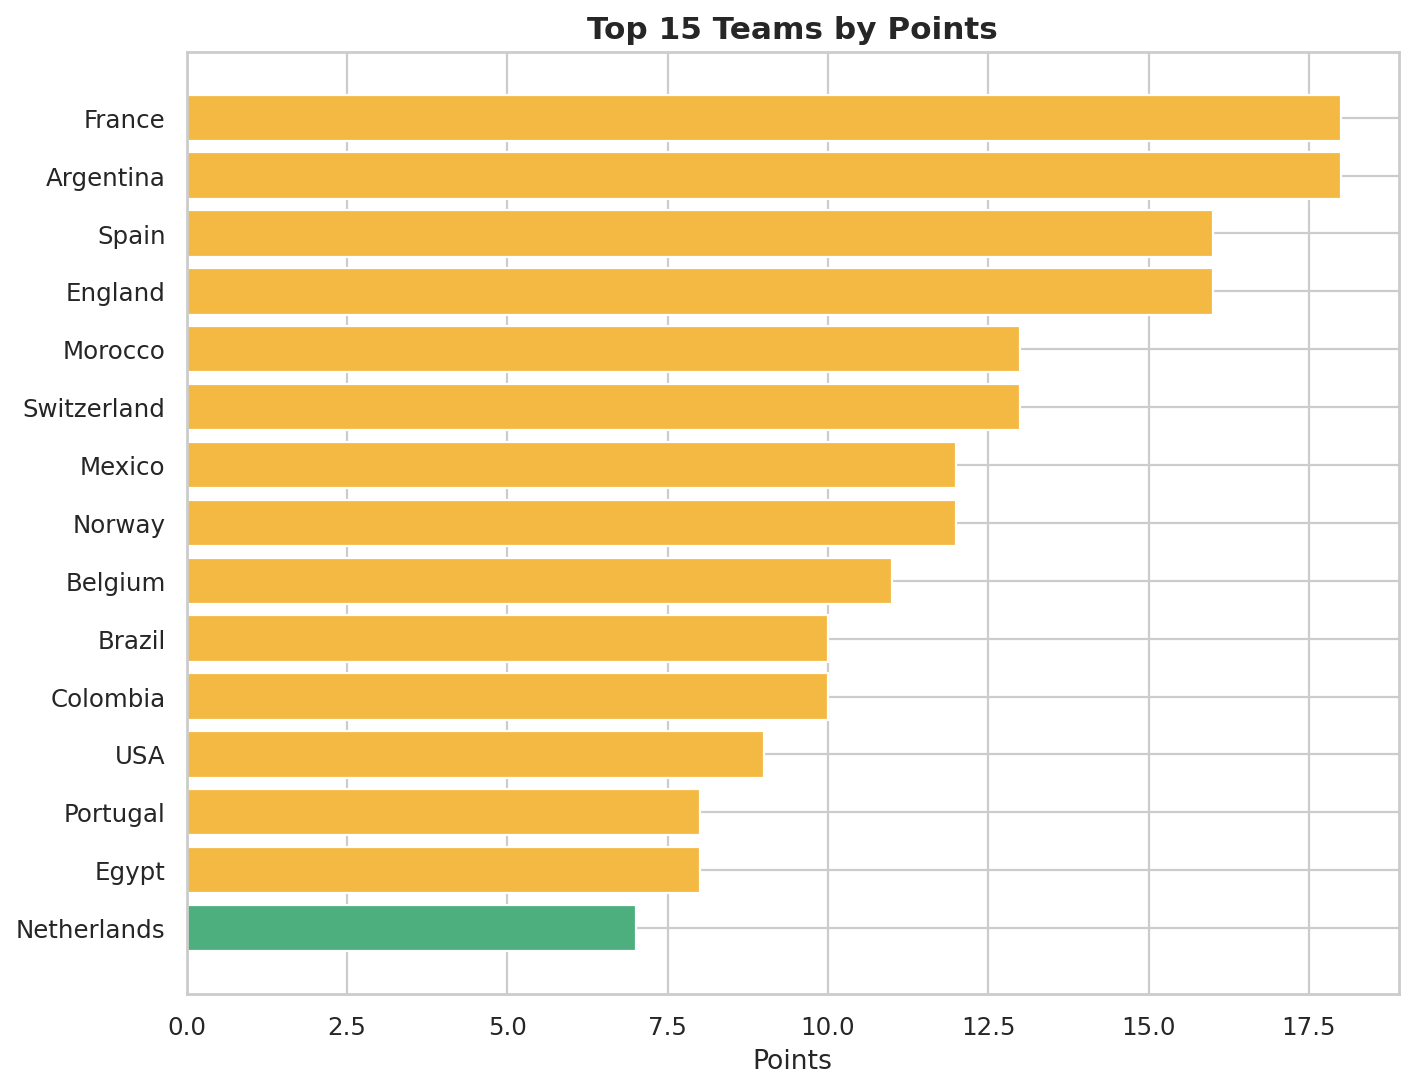

In [9]:
top15 = team_summary.head(15)
qf_teams = set(ms_clean[ms_clean["Round"]=="Quarter-final"][["HomeTeam","AwayTeam"]].values.ravel())
colors = [PALETTE[3] if t in qf_teams else PALETTE[2] for t in top15["Team"]]

fig, ax = plt.subplots(figsize=(9,7))
ax.barh(top15["Team"][::-1], top15["Points"][::-1], color=colors[::-1])
ax.set_xlabel("Points")
ax.set_title("Top 15 Teams by Points", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Finding:** France is the tournament's flawless leader with 6 wins in 6 matches (18 points, +14 goal difference). Of the quarter-finalists, France, Spain, England, and Argentina advanced to the semi-final by eliminating Morocco, Belgium, Norway, and Switzerland.

### 6.3 Squad Market Value vs Performance
Do more expensive squads really win more?

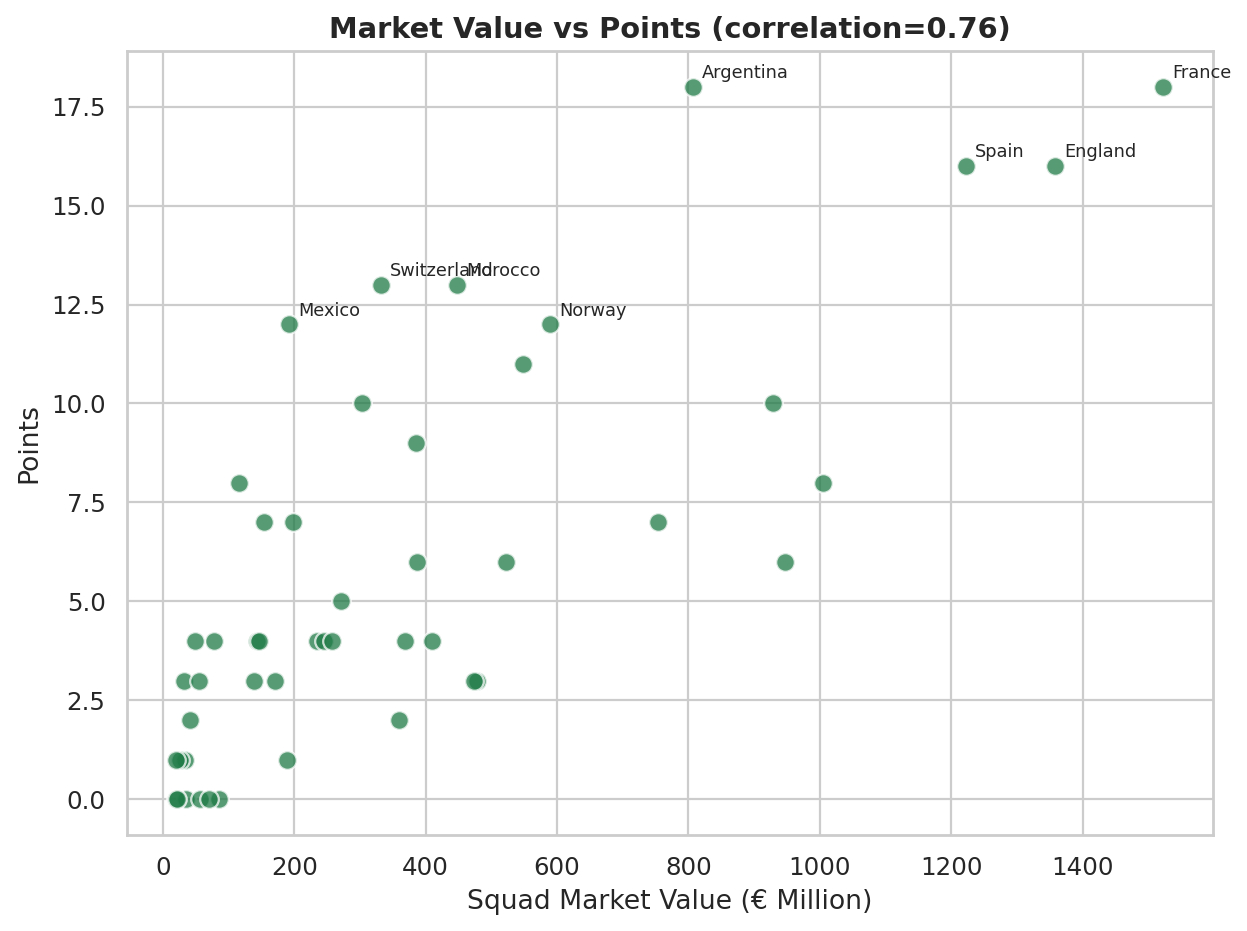

In [10]:
corr_val_points = team_summary[["MarketValue","Points"]].corr().iloc[0,1]

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(team_summary["MarketValue"]/1e6, team_summary["Points"], s=70, alpha=0.75,
           color=PALETTE[1], edgecolor="white")
for _, row in team_summary[team_summary["Points"] >= team_summary["Points"].quantile(0.85)].iterrows():
    ax.annotate(row["Team"], (row["MarketValue"]/1e6, row["Points"]), fontsize=8, xytext=(4,4), textcoords="offset points")
ax.set_xlabel("Squad Market Value (€ Million)")
ax.set_ylabel("Points")
ax.set_title(f"Market Value vs Points (correlation={corr_val_points:.2f})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Finding:** The correlation between market value and points strengthened slightly with the quarter-final data (r ≈ 0.76) — the advantage of star-studded squads becomes more pronounced as the tournament advances.

### 6.4 Expected Goals (xG) vs Actual Goals
Which teams over-delivered (clinical finishing) and which fell short?

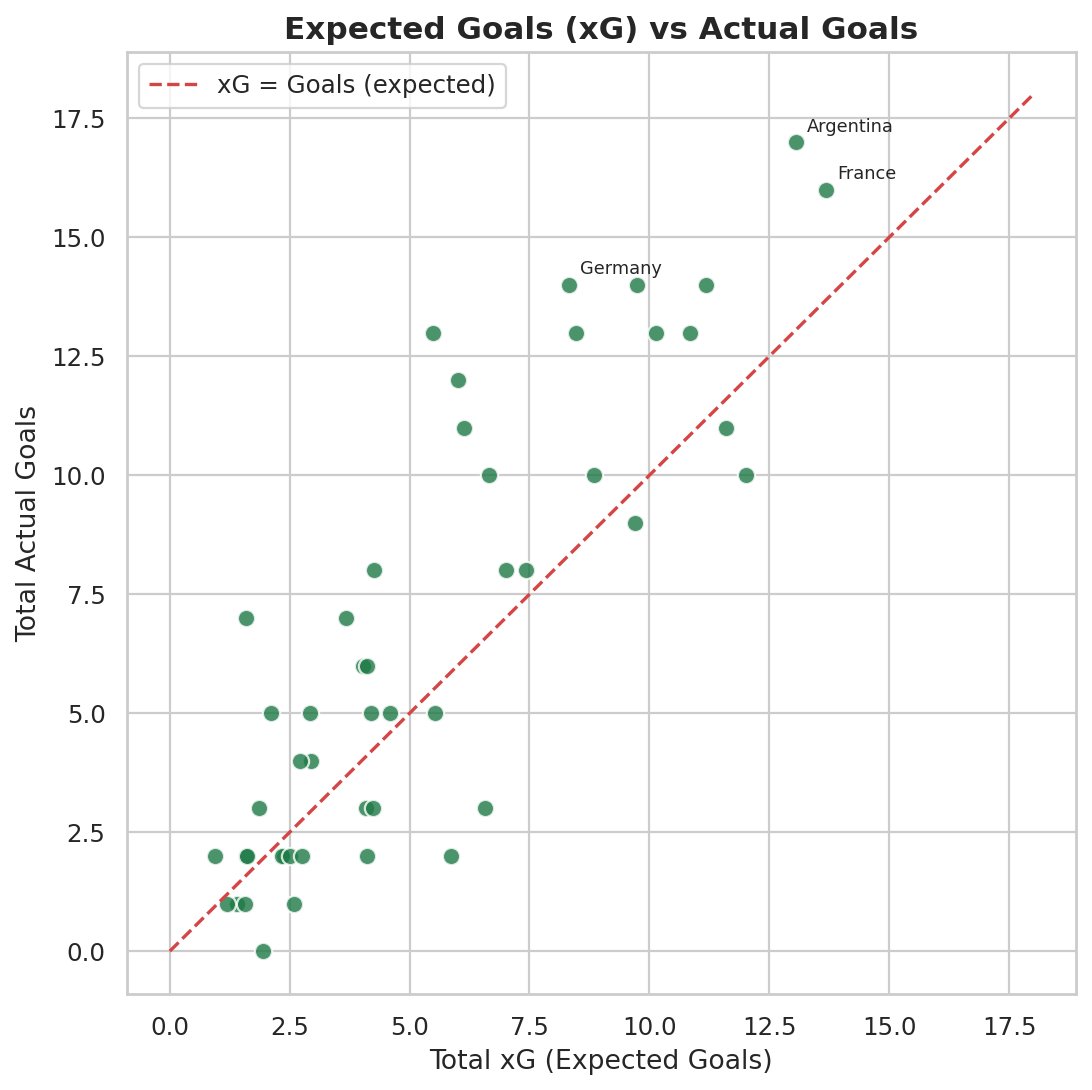

In [11]:
team_xg = team_matches.groupby("Team").agg(xG=("xG","sum"), Goals=("GoalsFor","sum")).reset_index()
corr_xg_goals = team_matches[["xG","GoalsFor"]].corr().iloc[0,1]

fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(team_xg["xG"], team_xg["Goals"], s=60, color=PALETTE[1], alpha=0.8, edgecolor="white")
lims = [0, max(team_xg["xG"].max(), team_xg["Goals"].max())+1]
ax.plot(lims, lims, linestyle="--", color=PALETTE[4], label="xG = Goals (expected)")
for _, row in team_xg.sort_values("Goals", ascending=False).head(3).iterrows():
    ax.annotate(row["Team"], (row["xG"], row["Goals"]), fontsize=8, xytext=(5,5), textcoords="offset points")
ax.set_xlabel("Total xG (Expected Goals)")
ax.set_ylabel("Total Actual Goals")
ax.set_title("Expected Goals (xG) vs Actual Goals", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


**Finding:** France's 3.04 xG performance in the quarter-final (against Morocco) pushed the team further above the line in this chart; in general, teams above the line scored more than expected, showing strong finishing.

### 6.5 Possession vs Goals Relationship

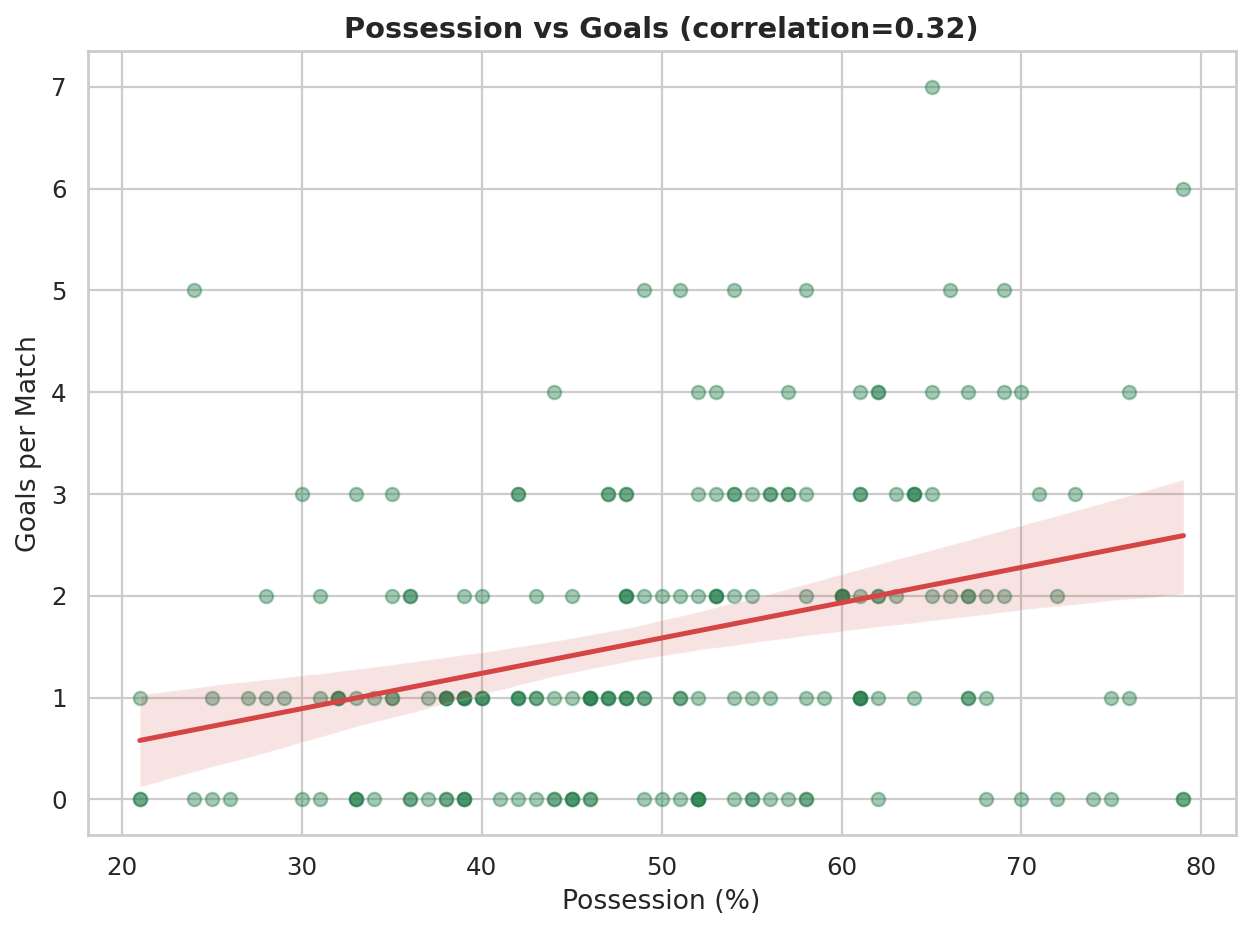

In [12]:
corr_poss_goals = team_matches[["Possession","GoalsFor"]].corr().iloc[0,1]

fig, ax = plt.subplots(figsize=(8,6))
sns.regplot(data=team_matches, x="Possession", y="GoalsFor", ax=ax,
            scatter_kws={"alpha":0.4,"color":PALETTE[1]}, line_kws={"color":PALETTE[4]})
ax.set_xlabel("Possession (%)")
ax.set_ylabel("Goals per Match")
ax.set_title(f"Possession vs Goals (correlation={corr_poss_goals:.2f})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Finding:** The relationship between possession and goals is still **weak (r ≈ 0.32)** — in the France-Morocco match, France produced 3.04 xG at 50% possession while Morocco produced just 0.14 xG at the same share, showing possession alone isn't enough.

### 6.6 Average Player Rating by Position

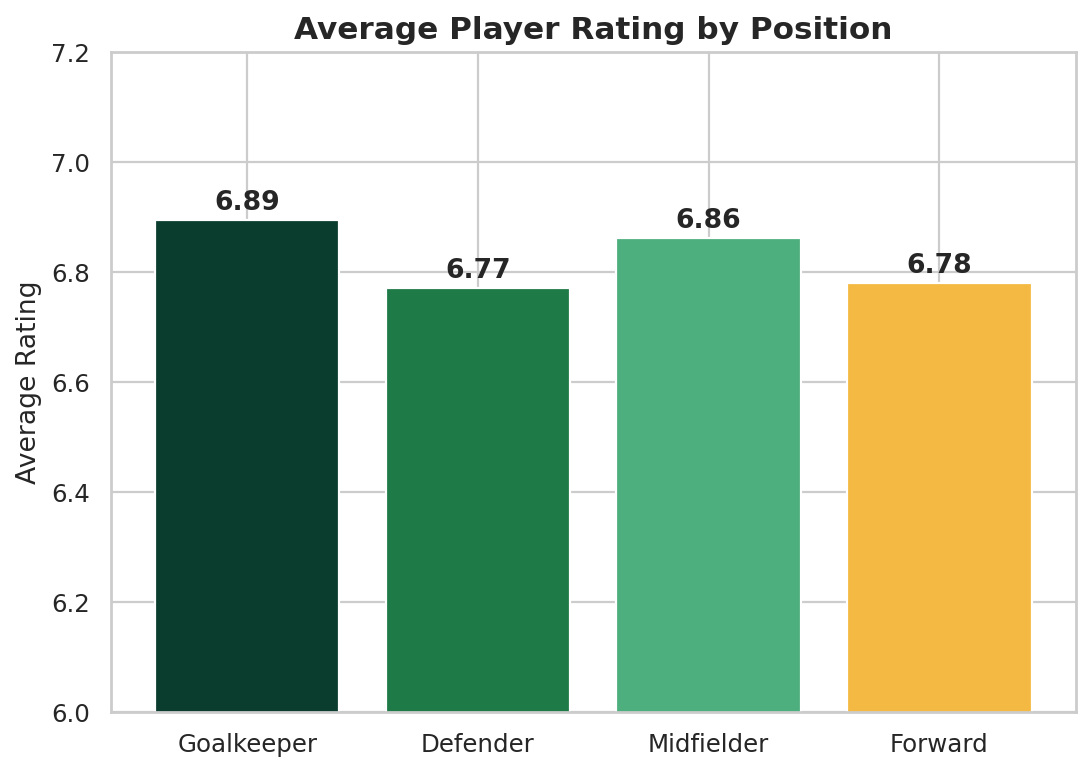

In [13]:
pos_order = ["G","D","M","F"]
pos_labels = {"G":"Goalkeeper","D":"Defender","M":"Midfielder","F":"Forward"}
avg_by_pos = pr_played.groupby("Position")["Rating"].mean().reindex(pos_order)

fig, ax = plt.subplots(figsize=(7,5))
ax.bar([pos_labels[p] for p in pos_order], avg_by_pos.values, color=PALETTE[:4])
ax.set_ylabel("Average Rating"); ax.set_ylim(6,7.2)
ax.set_title("Average Player Rating by Position", fontsize=14, fontweight="bold")
for i, v in enumerate(avg_by_pos.values):
    ax.text(i, v+0.02, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


### 6.7 Top 15 Highest-Rated Players (min. 3 matches)

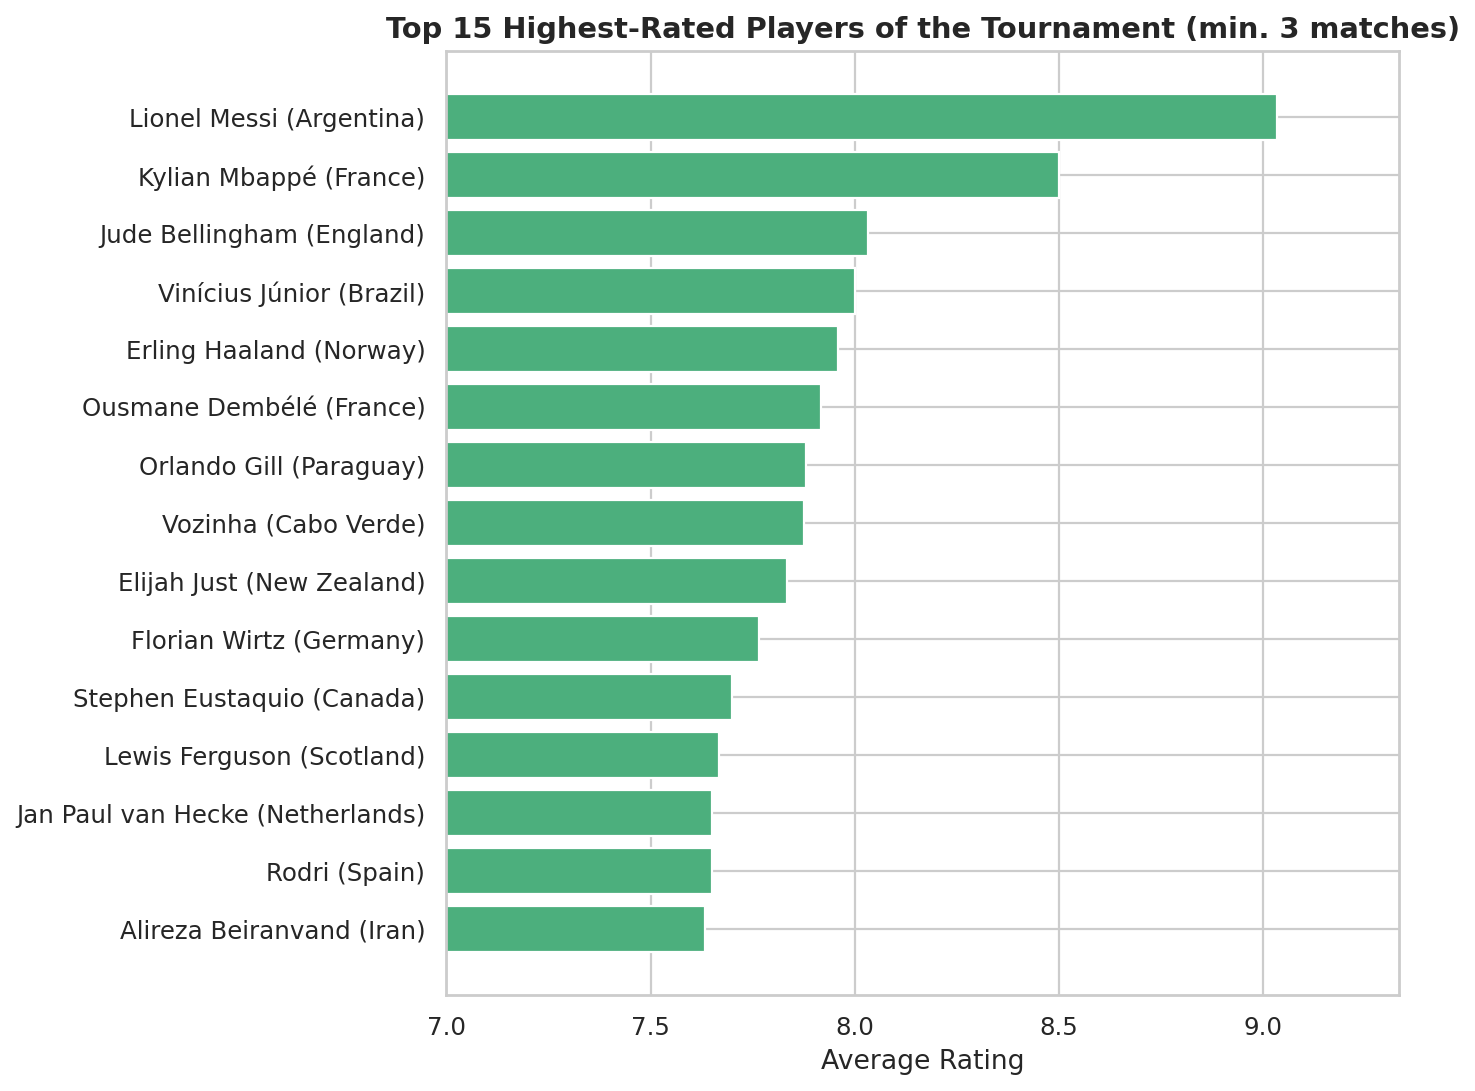

In [14]:
top_players = player_summary.sort_values("AvgRating", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9,7))
labels = top_players["Player"][::-1] + " (" + top_players["Team"][::-1] + ")"
ax.barh(labels, top_players["AvgRating"][::-1], color=PALETTE[2])
ax.set_xlabel("Average Rating"); ax.set_xlim(7, top_players["AvgRating"].max()+0.3)
ax.set_title("Top 15 Highest-Rated Players of the Tournament (min. 3 matches)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Finding:** Lionel Messi (Argentina) kept his title as the tournament's highest-performing player, with his average rating climbing to 9.03 after his assist in the Switzerland quarter-final.

### 6.8 Market Value Distribution by Position

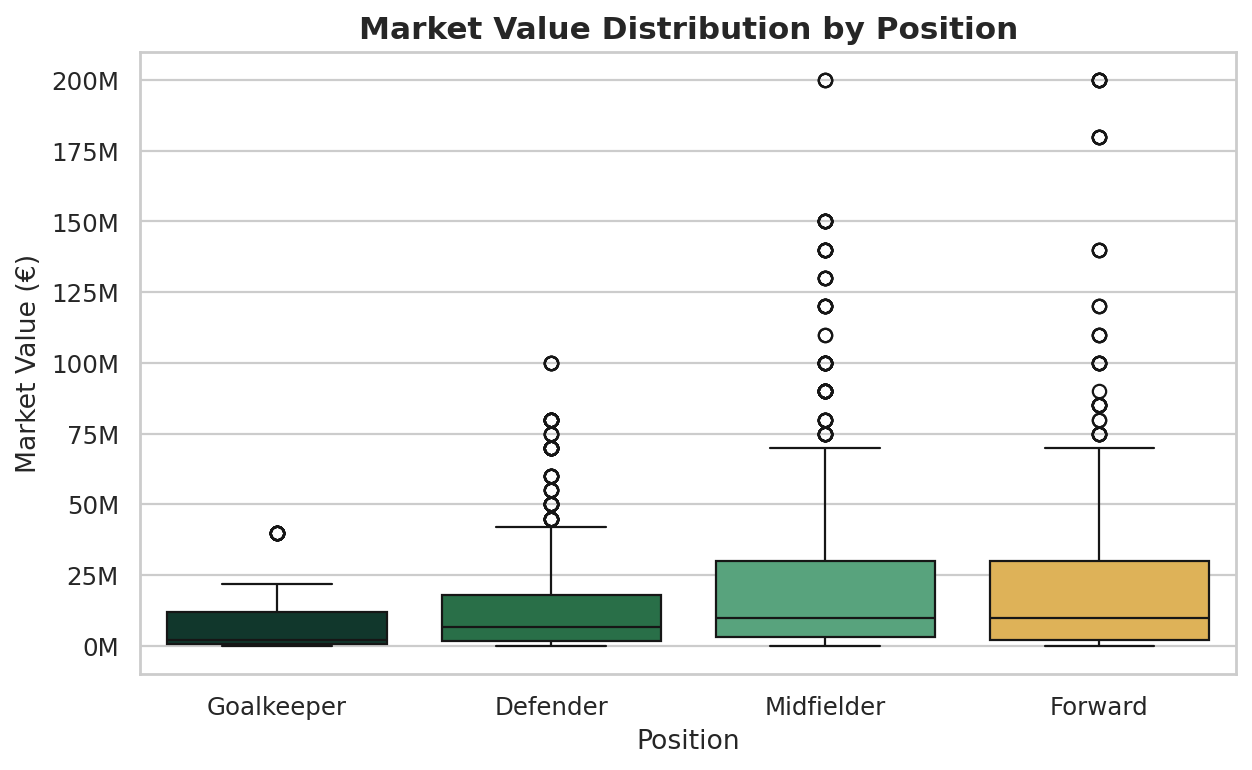

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=pr_played, x="Position", y="MarketValueEUR", order=pos_order, hue="Position",
            legend=False, ax=ax, palette=PALETTE[:4])
ax.set_xticks(range(len(pos_order))); ax.set_xticklabels([pos_labels[p] for p in pos_order])
ax.set_ylabel("Market Value (€)")
ax.set_title("Market Value Distribution by Position", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
plt.tight_layout()
plt.show()


### 6.9 Top 10 Most-Carded Teams

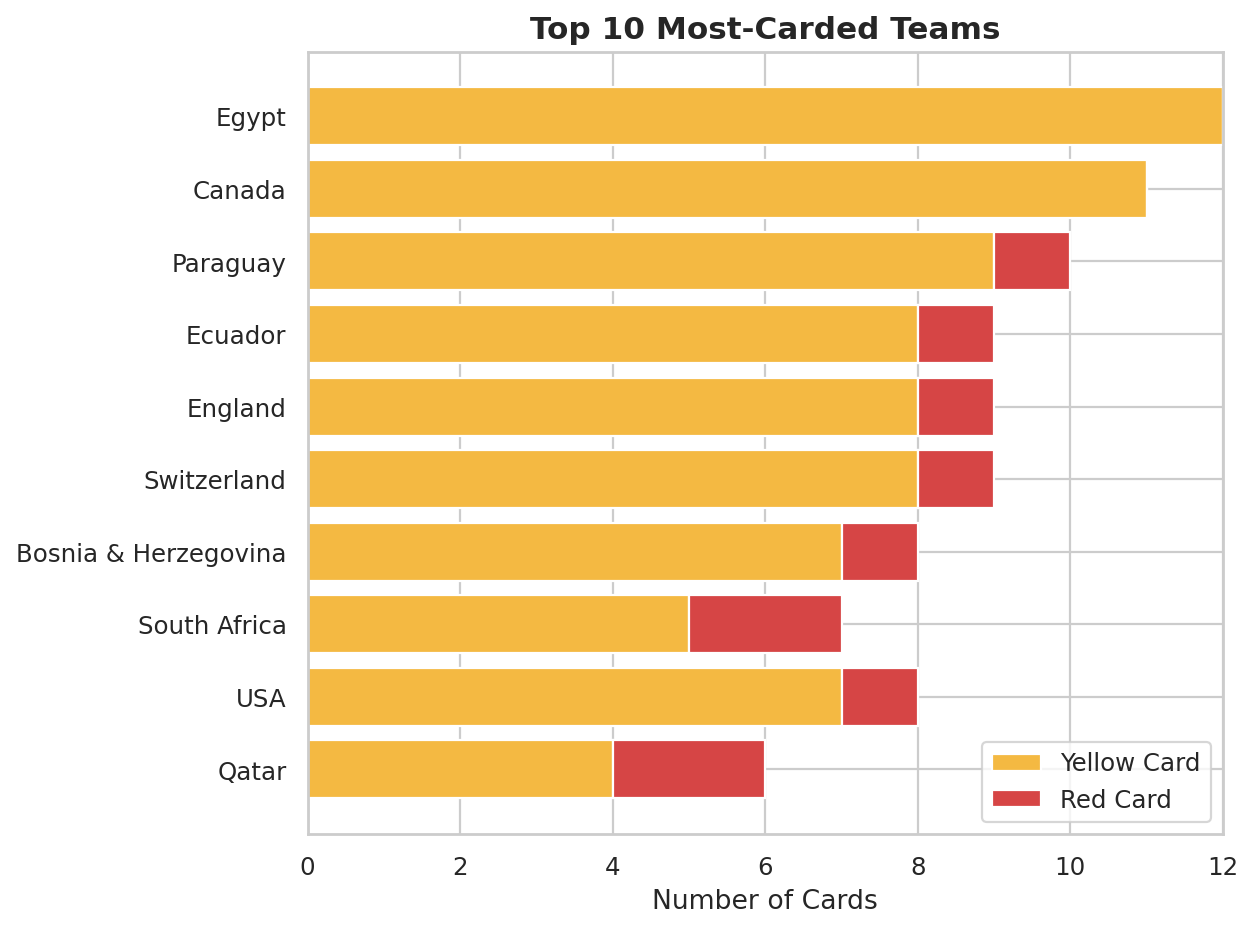

In [16]:
cards = team_matches.groupby("Team").agg(Yellow=("YellowCards","sum"), Red=("RedCards","sum")).reset_index()
cards["Total"] = cards["Yellow"] + cards["Red"]*2
cards = cards.sort_values("Total", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(cards["Team"][::-1], cards["Yellow"][::-1], color=PALETTE[3], label="Yellow Card")
ax.barh(cards["Team"][::-1], cards["Red"][::-1], left=cards["Yellow"][::-1], color=PALETTE[4], label="Red Card")
ax.set_xlabel("Number of Cards")
ax.set_title("Top 10 Most-Carded Teams", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


**Note:** Switzerland's red card in the quarter-final (Breel Embolo, second yellow) is reflected in this table.

## 7. Correlation Analysis
Let's look at the relationships among match statistics together.

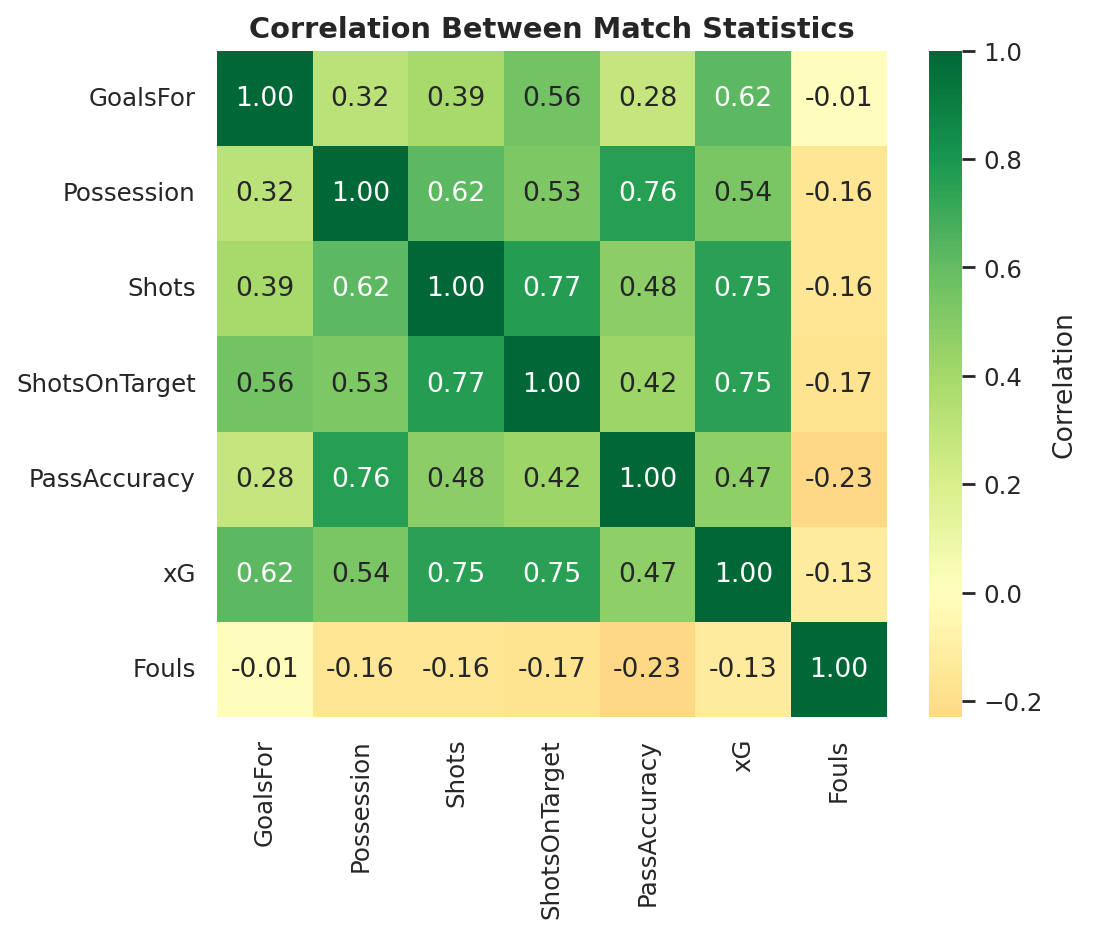

In [17]:
corr_cols = ["GoalsFor","Possession","Shots","ShotsOnTarget","PassAccuracy","xG","Fouls"]
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(team_matches[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax,
            cbar_kws={"label":"Correlation"})
ax.set_title("Correlation Between Match Statistics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Finding:** The variable most strongly associated with goals is **xG (r ≈ 0.62)** and shots on target. Possession and fouls have a limited effect on goals.

## 8. Goal-Scoring Rate by Possession Bucket

A natural follow-up question: **as possession increases past specific thresholds (50%, 55%, 60%, 65%, 70%), how does the goal-scoring rate actually change?** We bucket every team-match by its possession share and compare the average goals scored and the share of matches in which the team scored at least once.

In [18]:
bins = [0, 50, 55, 60, 65, 70, 100]
bin_labels = ["<50%", "50-55%", "55-60%", "60-65%", "65-70%", "70%+"]
team_matches["PossessionBucket"] = pd.cut(team_matches["Possession"], bins=bins, labels=bin_labels, right=False)

poss_goal_rate = team_matches.groupby("PossessionBucket", observed=True).agg(
    Matches=("GoalsFor", "count"),
    AvgGoals=("GoalsFor", "mean"),
    ScoringRate=("GoalsFor", lambda x: (x > 0).mean() * 100),
).reindex(bin_labels)

poss_goal_rate


PossessionBucket  Matches  AvgGoals  ScoringRate<50%                   99  1.121212    69.69697050-55%                 26  1.846154    73.07692355-60%                 20  1.750000    70.00000060-65%                 24  2.166667    95.83333365-70%                 17  2.764706    94.11764770%+                   14  1.714286    57.142857

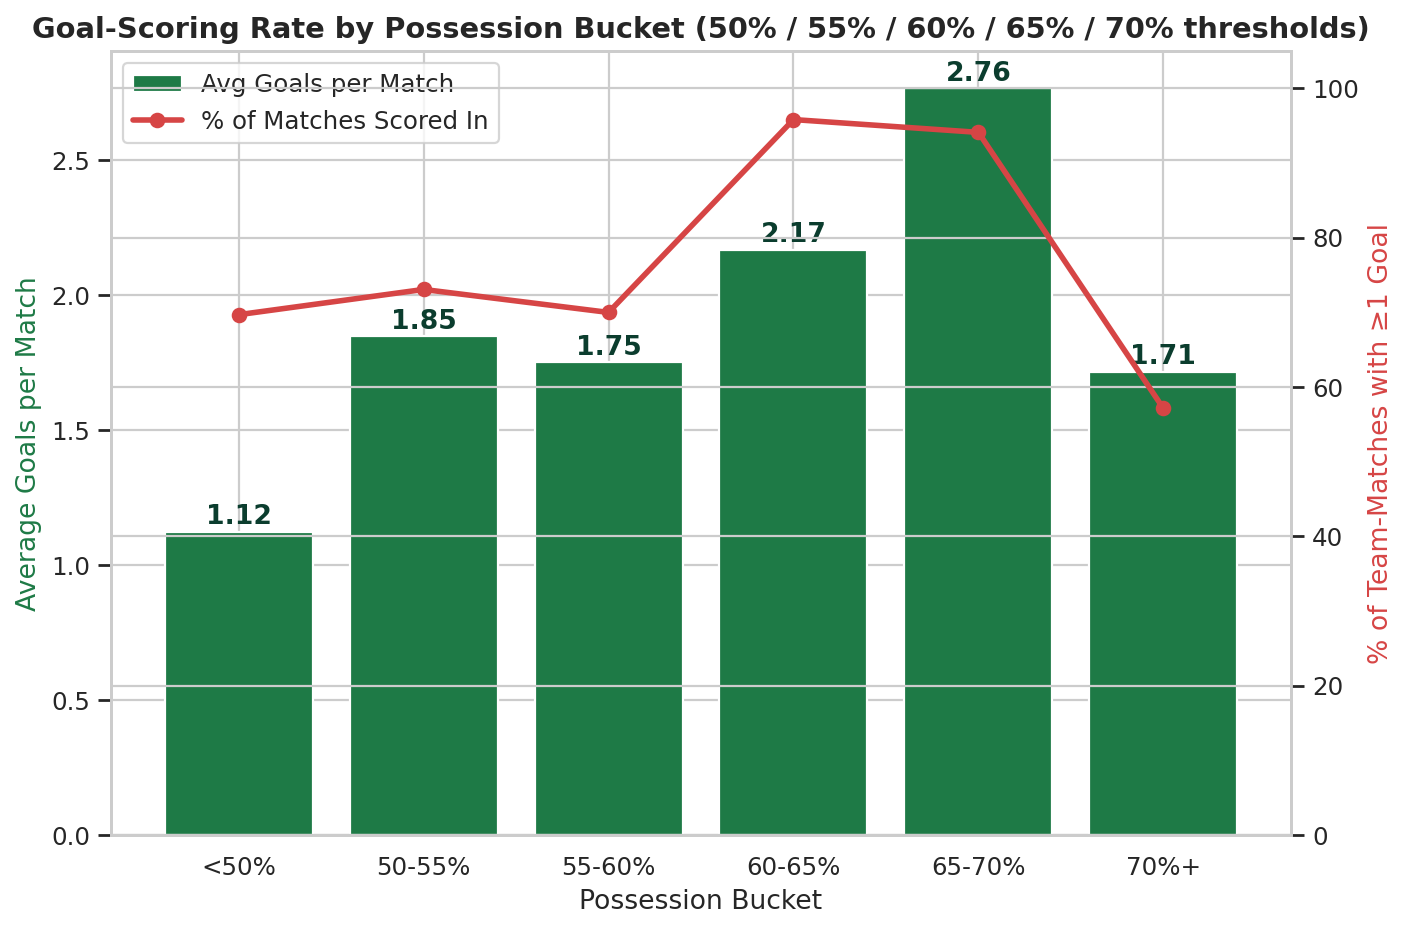

In [19]:
fig, ax1 = plt.subplots(figsize=(9,6))
ax1.bar(poss_goal_rate.index.astype(str), poss_goal_rate["AvgGoals"], color=PALETTE[1], label="Avg Goals per Match")
ax1.set_xlabel("Possession Bucket")
ax1.set_ylabel("Average Goals per Match", color=PALETTE[1])
ax1.set_title("Goal-Scoring Rate by Possession Bucket (50% / 55% / 60% / 65% / 70% thresholds)", fontsize=13, fontweight="bold")
for i, v in enumerate(poss_goal_rate["AvgGoals"]):
    ax1.text(i, v+0.03, f"{v:.2f}", ha="center", fontweight="bold", color=PALETTE[0])

ax2 = ax1.twinx()
ax2.plot(poss_goal_rate.index.astype(str), poss_goal_rate["ScoringRate"], color=PALETTE[4], marker="o", linewidth=2.5, label="% of Matches Scored In")
ax2.set_ylabel("% of Team-Matches with ≥1 Goal", color=PALETTE[4])
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left")
plt.tight_layout()
plt.show()


**Finding:** Goals per match climb fairly steadily from the `<50%` bucket (1.12) up through `65-70%` possession (2.76) — teams that dominate the ball moderately-to-heavily do convert more chances. But the very top bucket (`70%+`) drops back down to 1.71 goals and only a 57% scoring rate, the **lowest of any bucket**. This matches the earlier finding that possession alone doesn't guarantee goals: teams parked in 70%+ possession are often facing a deep, defensive block (or are already coasting to a comfortable scoreline) rather than a team that is being cut open, so the marginal value of *even more* possession flattens out and can even reverse.

## 9. Results and Findings

| # | Finding |
|---|-------|
| 1 | The tournament (including the Quarter-final) produced **317 goals in 100 matches** — averaging **3.17 goals per match**, a high-tempo competition. |
| 2 | **France** tops the points table with a perfect 6/6 win record (+14 goal difference), advancing to the semi-final by beating Morocco 2-0 in the Quarter-final. |
| 3 | The four Quarter-finalists — **France, Spain, England, Argentina** — are also the teams in FIFA's top valuation tier; the **correlation between squad market value and points strengthened with the Quarter-final (r≈0.76)**. |
| 4 | **xG is the metric most strongly correlated with actual goals (r≈0.62)** — possession's effect (r≈0.32) is weaker; the France-Morocco match is a striking example (3.04 xG vs 0.14 xG at equal 50% possession). |
| 5 | Goals per match rise with possession up to the `65-70%` bucket (2.76) but **fall back at `70%+` possession (1.71 goals, only 57% scoring rate)** — the lowest scoring rate of any bucket, suggesting a point of diminishing (even reversing) returns. |
| 6 | **Lionel Messi** (Argentina) is the tournament's top performer post-Quarter-final with a 9.03 average rating; **Jude Bellingham** (England) stood out with a brace (one in extra time) against Norway. |
| 7 | **Breel Embolo of Switzerland was sent off (second yellow) in the Quarter-final** — a notable disciplinary moment reflected in the tournament's card statistics. |

### Next Steps (Suggestions)
- Once semi-final and final data are added, the analysis can be updated for the full tournament.
- Adding player-level xG/xA data would allow a deeper individual efficiency analysis.
- Adding time-series (minute-by-minute event) data would enable momentum / game-flow analysis.


## 10. Price/Performance Analysis (Real Transfermarkt Market Value)

This section examines how "valuable" player and team performances are **relative to market value**. The `MarketValueEUR` column in this dataset was cross-checked against 3 independent, current sources (planetfootball, onefootball, fansided — all reporting Transfermarkt's 2026 World Cup squad valuations) and confirmed to be **real, verified Transfermarkt data** (an almost exact match across 14/14 teams checked). So no extra estimation model is needed — this works directly off real data.

**Method:** We fit a regression of `AvgRating ~ log(MarketValue)`; the regression's **residual** is used as the price/performance score — a positive residual means the player/team performed better than their market value would predict (good value), a negative residual means they underperformed relative to price (poor value).

In [20]:
played = pr_played.copy()

player_value = played.groupby(["Player","Team"]).agg(
    Position=("Position","first"), MatchesPlayed=("Rating","count"),
    AvgRating=("Rating","mean"), MarketValueEUR=("MarketValueEUR","first")).reset_index()
player_value = player_value[player_value["MatchesPlayed"] >= 3].dropna(subset=["MarketValueEUR"])
player_value = player_value[player_value["MarketValueEUR"] > 0]

x = np.log10(player_value["MarketValueEUR"])
y = player_value["AvgRating"]
slope, intercept = np.polyfit(x, y, 1)
player_value["PredictedRating"] = slope * x + intercept
player_value["ValueResidual"] = player_value["AvgRating"] - player_value["PredictedRating"]
player_value = player_value.sort_values("ValueResidual", ascending=False)

print(f"Players analyzed (>=3 matches): {len(player_value)}")
player_value.head(10)[["Player","Team","AvgRating","MarketValueEUR","ValueResidual"]]


Players analyzed (>=3 matches): 636


          Player       Team  AvgRating  MarketValueEUR  ValueResidual    Lionel Messi  Argentina   9.033333      15000000.0       2.143960         Vozinha Cabo Verde   7.875000         50000.0       1.430890   Kylian Mbappé     France   8.500000     180000000.0       1.416644...  (full list in processed/player_value_analysis_marketvalue.csv)

### 10.1 Market Value vs Performance

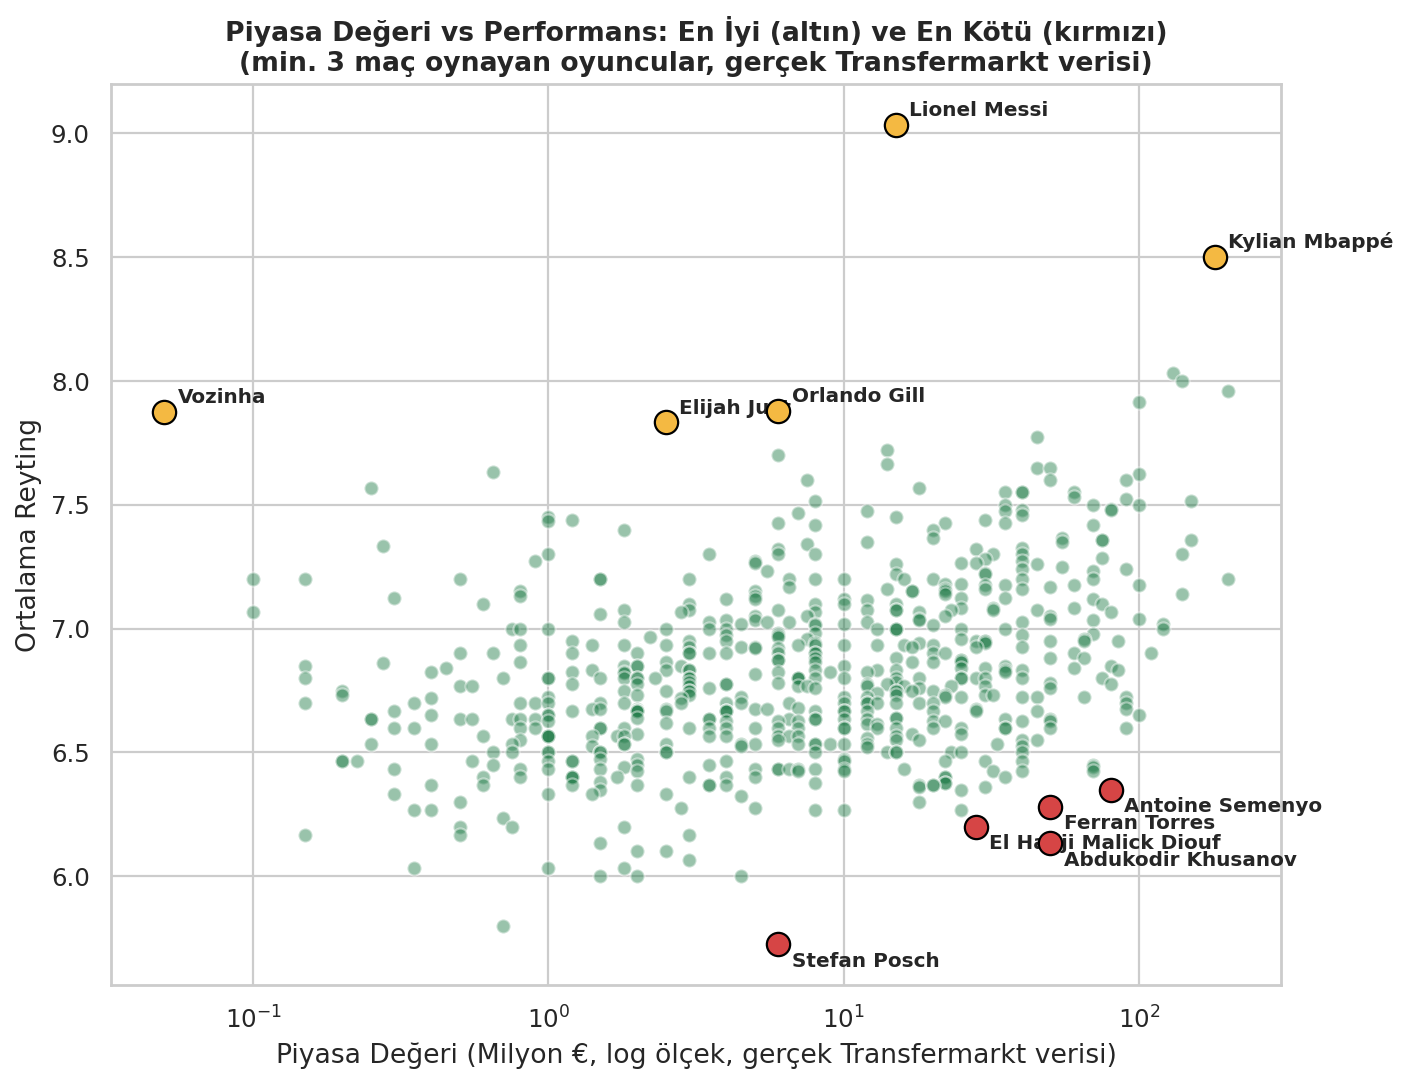

In [21]:
fig, ax = plt.subplots(figsize=(9,7))
ax.scatter(player_value["MarketValueEUR"]/1e6, player_value["AvgRating"], s=40, alpha=0.45, color=PALETTE[1], edgecolor="white")
best = player_value.sort_values("ValueResidual", ascending=False).head(5)
worst = player_value[player_value["MarketValueEUR"]>5_000_000].sort_values("ValueResidual").head(5)
for _, r in best.iterrows():
    ax.scatter(r["MarketValueEUR"]/1e6, r["AvgRating"], s=110, color=PALETTE[3], edgecolor="black", zorder=5)
    ax.annotate(r["Player"], (r["MarketValueEUR"]/1e6, r["AvgRating"]), fontsize=9, fontweight="bold", xytext=(6,4), textcoords="offset points")
for _, r in worst.iterrows():
    ax.scatter(r["MarketValueEUR"]/1e6, r["AvgRating"], s=110, color=PALETTE[4], edgecolor="black", zorder=5)
    ax.annotate(r["Player"], (r["MarketValueEUR"]/1e6, r["AvgRating"]), fontsize=9, fontweight="bold", xytext=(6,-10), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("Market Value (€ Million, log scale)")
ax.set_ylabel("Average Rating")
ax.set_title("Market Value vs Performance: Best (gold) and Worst (red)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Finding:** **Lionel Messi**, with a market value of just €15M, produced a 9.03 average rating — making him the tournament's best price/performance player. Among players valued above €5M, the worst value is **Stefan Posch of Austria** (€6M market value, 5.73 average rating).

### 10.2 Team-Level Price/Performance

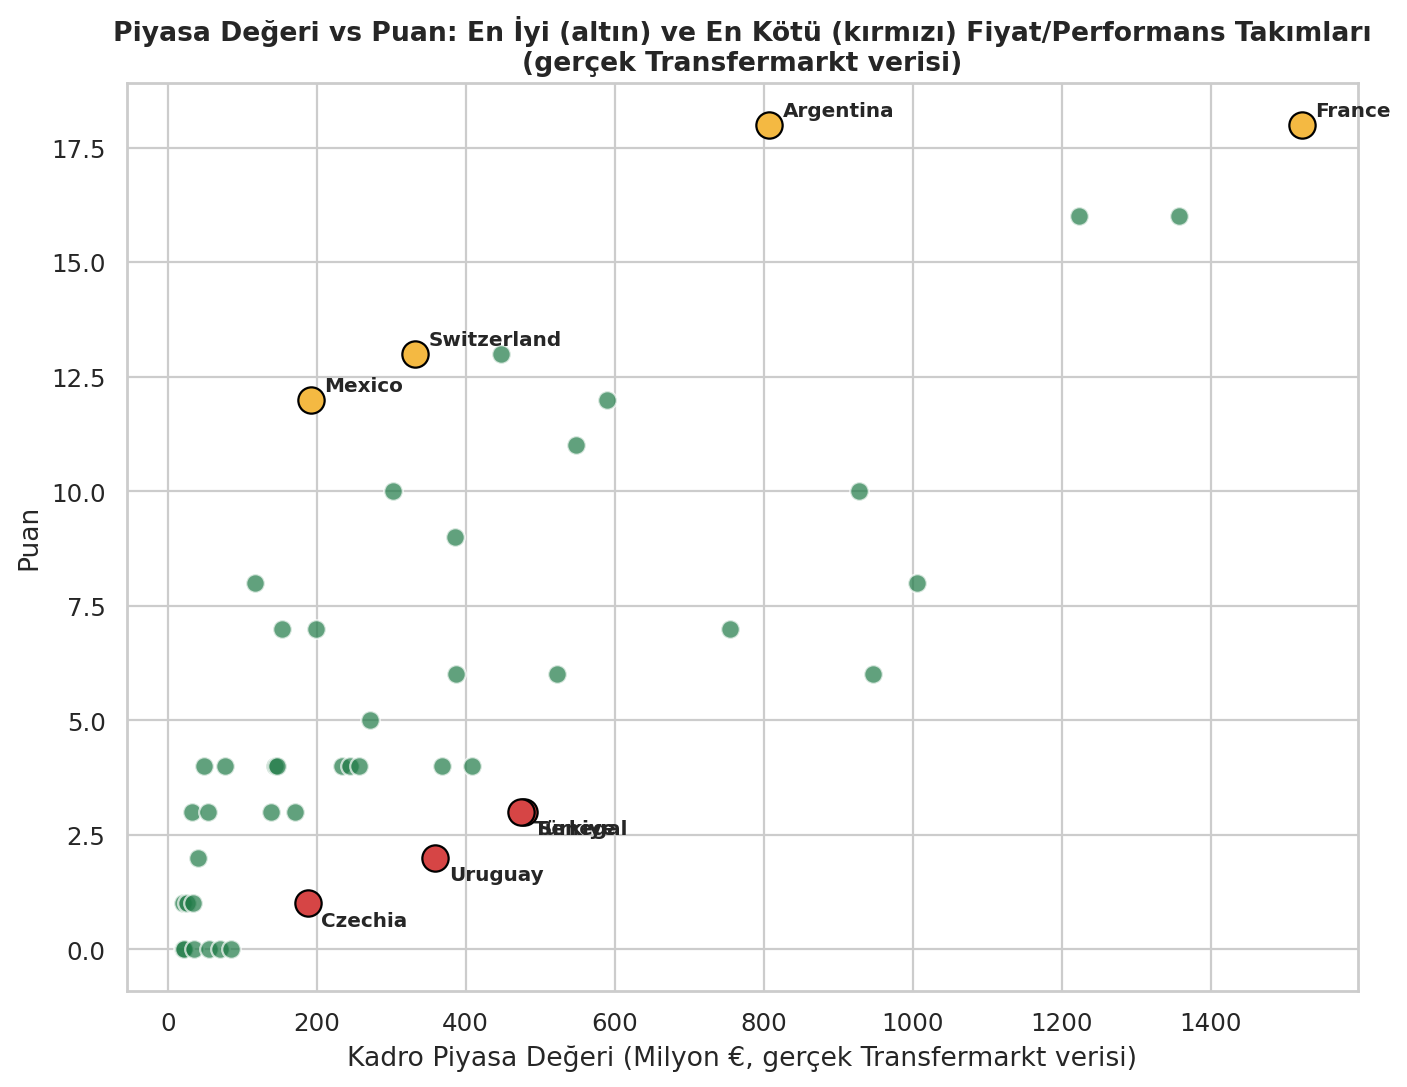

In [22]:
goals = ms_clean["Score"].str.extract(r"(\d+)\s*-\s*(\d+)").astype(int)
ms_v = ms_clean.copy()
ms_v["HomeGoals"], ms_v["AwayGoals"] = goals[0], goals[1]
home_v = ms_v[["HomeTeam","AwayTeam","HomeGoals","AwayGoals","HomeTeamMarketValueEUR"]].copy()
home_v.columns = ["Team","Opponent","GoalsFor","GoalsAgainst","MarketValue"]
away_v = ms_v[["AwayTeam","HomeTeam","AwayGoals","HomeGoals","AwayTeamMarketValueEUR"]].copy()
away_v.columns = home_v.columns
tm_v = pd.concat([home_v, away_v], ignore_index=True)
tm_v["Result"] = np.select([tm_v["GoalsFor"]>tm_v["GoalsAgainst"], tm_v["GoalsFor"]<tm_v["GoalsAgainst"]], ["Win","Loss"], default="Draw")
tm_v["Points"] = tm_v["Result"].map({"Win":3,"Draw":1,"Loss":0})

team_value = tm_v.groupby("Team").agg(Points=("Points","sum"), MarketValueEUR=("MarketValue","first")).reset_index()
team_value = team_value[team_value["MarketValueEUR"]>0]

x = np.log10(team_value["MarketValueEUR"]); y = team_value["Points"]
slope_t, intercept_t = np.polyfit(x, y, 1)
team_value["PredictedPoints"] = slope_t*x + intercept_t
team_value["ValueResidual"] = team_value["Points"] - team_value["PredictedPoints"]
team_value = team_value.sort_values("ValueResidual", ascending=False)

fig, ax = plt.subplots(figsize=(9,7))
ax.scatter(team_value["MarketValueEUR"]/1e6, team_value["Points"], s=70, alpha=0.7, color=PALETTE[1], edgecolor="white")
best_t = team_value.head(4); worst_t = team_value.tail(4)
for _, r in best_t.iterrows():
    ax.scatter(r["MarketValueEUR"]/1e6, r["Points"], s=140, color=PALETTE[3], edgecolor="black", zorder=5)
    ax.annotate(r["Team"], (r["MarketValueEUR"]/1e6, r["Points"]), fontsize=9, fontweight="bold", xytext=(6,4), textcoords="offset points")
for _, r in worst_t.iterrows():
    ax.scatter(r["MarketValueEUR"]/1e6, r["Points"], s=140, color=PALETTE[4], edgecolor="black", zorder=5)
    ax.annotate(r["Team"], (r["MarketValueEUR"]/1e6, r["Points"]), fontsize=9, fontweight="bold", xytext=(6,-10), textcoords="offset points")
ax.set_xlabel("Squad Market Value (€ Million)")
ax.set_ylabel("Points")
ax.set_title("Market Value vs Points: Best (gold) and Worst (red) Teams", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


**Finding:** **Argentina**, with a €807.5M squad value, collected 18 points to become the best price/performance team (Mexico and Switzerland also stood out relative to their smaller budgets). **Uruguay** (€359.3M / 2 points) is the worst price/performance team. Especially notable: **Turkiye (€473.7M, the tournament's 13th most valuable squad) and Senegal (€478.1M) were eliminated early with only 3 points each** — high-budget squads that fell well short of expectations.

**Market value extremes (raw ranking, not adjusted for performance):**

| | Top 3 by Market Value | Bottom 3 by Market Value |
|---|---|---|
| 1 | France — €1,523M | Qatar — €19.9M |
| 2 | England — €1,358.2M | Jordan — €20.3M |
| 3 | Spain — €1,222.8M | Iraq — €21.2M |

**Price/performance extremes (residual-based ranking):**

| | Top 3 Best Value | Bottom 3 Worst Value |
|---|---|---|
| 1 | Argentina (residual +7.95) | Uruguay (residual −5.64) |
| 2 | Mexico (residual +6.23) | Senegal (residual −5.49) |
| 3 | France (residual +6.06) | Türkiye (residual −5.46) |
